Cell 1 — Import libraries và path

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


# =====================================================
# Import project paths
# =====================================================
# Nếu notebook nằm trong /notebooks, thêm PROJECT_ROOT vào sys.path
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.path import (
    DATA_PREPROCESSED_FILE,
    FIGURES_DIR,
    DATA_REPORTS_DIR,
    check_and_create_directories
)


# =====================================================
# Create output folders if missing
# =====================================================
check_and_create_directories(auto_create=True)

EDA_FIGURES_DIR = FIGURES_DIR / "eda"
EDA_TABLES_DIR = DATA_REPORTS_DIR / "eda"

EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EDA_TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Paths loaded successfully")
print(f"Input data path: {DATA_PREPROCESSED_FILE}")
print(f"EDA figures dir: {EDA_FIGURES_DIR}")
print(f"EDA tables dir: {EDA_TABLES_DIR}")

✅ Tất cả các thư mục cấu trúc dự án đã đầy đủ và sẵn sàng!
✅ Paths loaded successfully
Input data path: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\data\preprocessed_data\preprocessed_data.csv
EDA figures dir: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda
EDA tables dir: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda


Cell 2 — Load dataset

In [2]:
# =====================================================
# Load preprocessed dataset
# =====================================================
df = pd.read_csv(DATA_PREPROCESSED_FILE)

print("✅ Dataset loaded successfully")
print(f"Shape: {df.shape}")

display(df.head())

✅ Dataset loaded successfully
Shape: (7043, 16)


,ID,Churn,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Tenure,Contract,PaymentMethod,PaperlessBilling,MonthlyCharges,TotalCharges
0,3668-QPYBK,1,0,0,No,DSL,1,1,0,0,2,1,Mailed check,1,53.85,108.15
1,9237-HQITU,1,0,0,Yes,Fiber optic,0,0,0,0,2,1,Electronic check,1,70.70,151.65
2,9305-CDSKC,1,0,0,Yes,Fiber optic,0,0,1,0,8,1,Electronic check,1,99.65,820.50
3,7892-POOKP,1,0,1,Yes,Fiber optic,0,0,1,1,28,1,Electronic check,1,104.80,3046.05
4,0280-XJGEX,1,0,0,Yes,Fiber optic,0,1,1,0,49,1,Bank transfer (automatic),1,103.70,5036.30


Cell 3 — Basic data inspection

In [3]:
# =====================================================
# Basic dataset inspection
# =====================================================
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing_table = df.isna().sum().to_frame("missing_count")
missing_table["missing_percent"] = (missing_table["missing_count"] / len(df) * 100).round(2)
display(missing_table)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic descriptive statistics:")
display(df.describe(include="all").T)

Dataset shape:
(7043, 16)

Column names:
['ID', 'Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'Tenure', 'Contract', 'PaymentMethod', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']

Data types:


,dtype
ID,object
Churn,int64
SeniorCitizen,int64
Partner,int64
Dependents,object
InternetService,object
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64
TechSupport,int64



Missing values:


,missing_count,missing_percent
ID,0,0.0
Churn,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0
OnlineBackup,0,0.0
DeviceProtection,0,0.0
TechSupport,0,0.0



Duplicate rows:
0

Basic descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,7043.0,NaN,NaN,NaN,0.26537,0.441561,0.0,0.0,0.0,1.0,1.0
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043.0,NaN,NaN,NaN,0.483033,0.499748,0.0,0.0,0.0,1.0,1.0
Dependents,7043,2,No,5416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043.0,NaN,NaN,NaN,0.286668,0.452237,0.0,0.0,0.0,1.0,1.0
OnlineBackup,7043.0,NaN,NaN,NaN,0.344881,0.475363,0.0,0.0,0.0,1.0,1.0
DeviceProtection,7043.0,NaN,NaN,NaN,0.343888,0.475038,0.0,0.0,0.0,1.0,1.0
TechSupport,7043.0,NaN,NaN,NaN,0.290217,0.453895,0.0,0.0,0.0,1.0,1.0


Cell 4 — Define helper functions

In [4]:
# =====================================================
# Helper functions for EDA
# =====================================================

def save_current_figure(filename: str):
    """
    Save current matplotlib figure with Springer/report-ready quality.
    """
    output_path = EDA_FIGURES_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"✅ Saved figure: {output_path}")


def save_table(dataframe: pd.DataFrame, filename: str):
    """
    Save EDA table to CSV.
    """
    output_path = EDA_TABLES_DIR / filename
    dataframe.to_csv(output_path, index=False)
    print(f"✅ Saved table: {output_path}")


def clean_label(value):
    """
    Clean label for display.
    """
    return str(value).replace("_", " ").strip()


def churn_rate_table(dataframe: pd.DataFrame, group_col: str, target_col: str = "Churn"):
    """
    Create churn rate summary table by a categorical/group column.
    """
    table = (
        dataframe
        .groupby(group_col, dropna=False)
        .agg(
            total_customers=(target_col, "count"),
            churn_customers=(target_col, "sum"),
            churn_rate=(target_col, "mean")
        )
        .reset_index()
    )

    table["churn_rate_percent"] = (table["churn_rate"] * 100).round(2)
    table = table.sort_values("churn_rate_percent", ascending=False)

    return table


def plot_churn_rate_bar(dataframe: pd.DataFrame, group_col: str, title: str, filename: str):
    """
    Plot churn rate by group column.
    """
    table = churn_rate_table(dataframe, group_col)

    plt.figure(figsize=(9, 5))
    ax = sns.barplot(
        data=table,
        x=group_col,
        y="churn_rate_percent"
    )

    plt.title(title, fontfamily="serif", fontsize=14)
    plt.xlabel(clean_label(group_col), fontfamily="serif")
    plt.ylabel("Churn Rate (%)", fontfamily="serif")
    plt.xticks(rotation=30, ha="right")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=8)

    plt.tight_layout()
    save_current_figure(filename)
    plt.show()

    return table

Cell 5 — Optional label mapping

In [5]:
# =====================================================
# Create EDA-friendly copy with readable labels
# =====================================================
df_eda = df.copy()

# Target label
if "Churn" in df_eda.columns:
    df_eda["Churn_Label"] = df_eda["Churn"].map({
        0: "Non-Churn",
        1: "Churn"
    }).fillna(df_eda["Churn"].astype(str))

# Binary label mapping
binary_label_cols = [
    "SeniorCitizen",
    "Partner",
    "PaperlessBilling",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

for col in binary_label_cols:
    if col in df_eda.columns:
        df_eda[f"{col}_Label"] = df_eda[col].map({
            0: "No",
            1: "Yes"
        }).fillna(df_eda[col].astype(str))

# =====================================================
# Contract mapping
# =====================================================
# Contract unique values: [1, 12, 24]
# 1  = Month-to-month
# 12 = One year
# 24 = Two year

if "Contract" in df_eda.columns:
    contract_unique = sorted(df_eda["Contract"].dropna().unique().tolist())
    print("Contract unique values:", contract_unique)

    contract_mapping = {
        1: "Month-to-month",
        12: "One year",
        24: "Two year"
    }

    df_eda["Contract_Label"] = (
        df_eda["Contract"]
        .map(contract_mapping)
        .fillna(df_eda["Contract"].astype(str))
    )

display(df_eda[["Contract", "Contract_Label"]].head())

display(df_eda.head())

Contract unique values: [1, 12, 24]


,Contract,Contract_Label
0,1,Month-to-month
1,1,Month-to-month
2,1,Month-to-month
3,1,Month-to-month
4,1,Month-to-month


,ID,Churn,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,TotalCharges,Churn_Label,SeniorCitizen_Label,Partner_Label,PaperlessBilling_Label,OnlineSecurity_Label,OnlineBackup_Label,DeviceProtection_Label,TechSupport_Label,Contract_Label
0,3668-QPYBK,1,0,0,No,DSL,1,1,0,0,...,108.15,Churn,No,No,Yes,Yes,Yes,No,No,Month-to-month
1,9237-HQITU,1,0,0,Yes,Fiber optic,0,0,0,0,...,151.65,Churn,No,No,Yes,No,No,No,No,Month-to-month
2,9305-CDSKC,1,0,0,Yes,Fiber optic,0,0,1,0,...,820.50,Churn,No,No,Yes,No,No,Yes,No,Month-to-month
3,7892-POOKP,1,0,1,Yes,Fiber optic,0,0,1,1,...,3046.05,Churn,No,Yes,Yes,No,No,Yes,Yes,Month-to-month
4,0280-XJGEX,1,0,0,Yes,Fiber optic,0,1,1,0,...,5036.30,Churn,No,No,Yes,No,Yes,Yes,No,Month-to-month


Cell 6 — Target distribution

,Churn,count,percent
0,0,5174,73.46
1,1,1869,26.54


✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_distribution.csv
✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_distribution.png


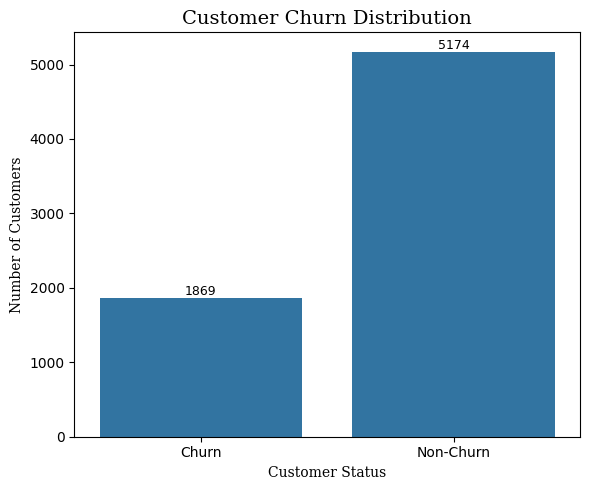

In [6]:
# =====================================================
# Churn distribution
# =====================================================
churn_summary = (
    df_eda["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="count")
)

churn_summary["percent"] = (churn_summary["count"] / churn_summary["count"].sum() * 100).round(2)

display(churn_summary)
save_table(churn_summary, "churn_distribution.csv")

plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=df_eda,
    x="Churn_Label"
)

plt.title("Customer Churn Distribution", fontfamily="serif", fontsize=14)
plt.xlabel("Customer Status", fontfamily="serif")
plt.ylabel("Number of Customers", fontfamily="serif")

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.tight_layout()
save_current_figure("churn_distribution.png")
plt.show()

Cell 7 — Churn rate by categorical variables

Categorical columns used for churn-rate analysis:
['Contract_Label', 'InternetService', 'PaymentMethod', 'PaperlessBilling_Label', 'SeniorCitizen_Label', 'Partner_Label', 'Dependents', 'OnlineSecurity_Label', 'OnlineBackup_Label', 'DeviceProtection_Label', 'TechSupport_Label']
✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_contract_label.png


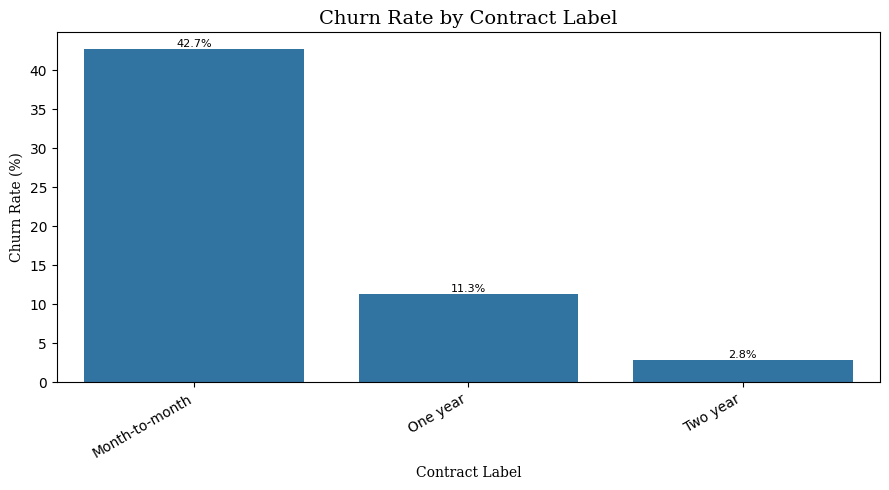

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_contract_label.csv


,Contract_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
0,Month-to-month,3875,1655,0.427097,42.71
1,One year,1473,166,0.112695,11.27
2,Two year,1695,48,0.028319,2.83


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_internetservice.png


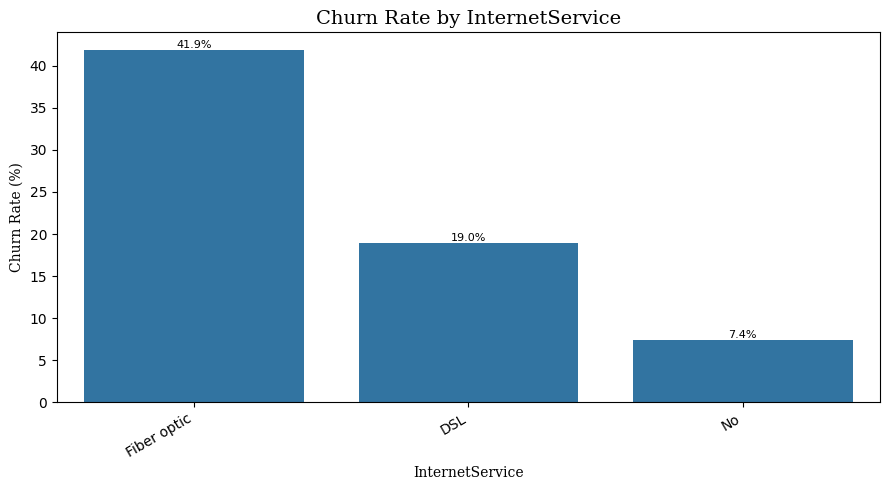

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_internetservice.csv


,InternetService,total_customers,churn_customers,churn_rate,churn_rate_percent
1,Fiber optic,3096,1297,0.418928,41.89
0,DSL,2421,459,0.189591,18.96
2,No,1526,113,0.074050,7.40


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_paymentmethod.png


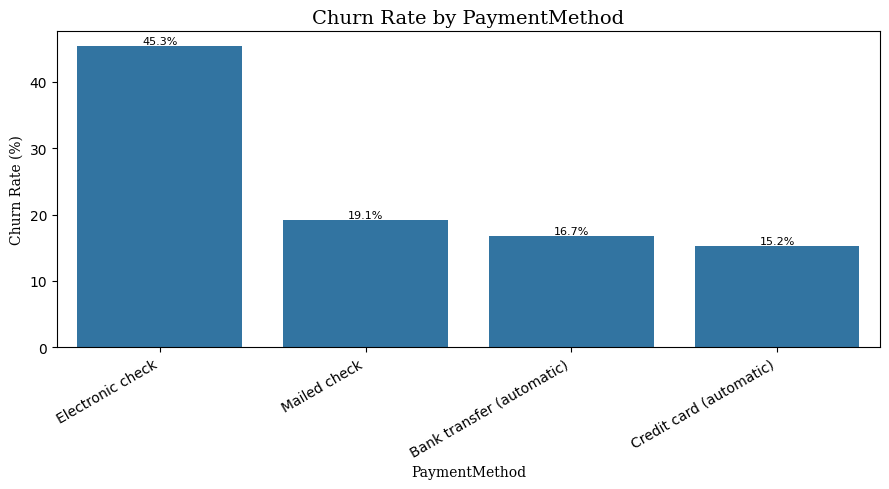

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_paymentmethod.csv


,PaymentMethod,total_customers,churn_customers,churn_rate,churn_rate_percent
2,Electronic check,2365,1071,0.452854,45.29
3,Mailed check,1612,308,0.191067,19.11
0,Bank transfer (automatic),1544,258,0.167098,16.71
1,Credit card (automatic),1522,232,0.152431,15.24


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_paperlessbilling_label.png


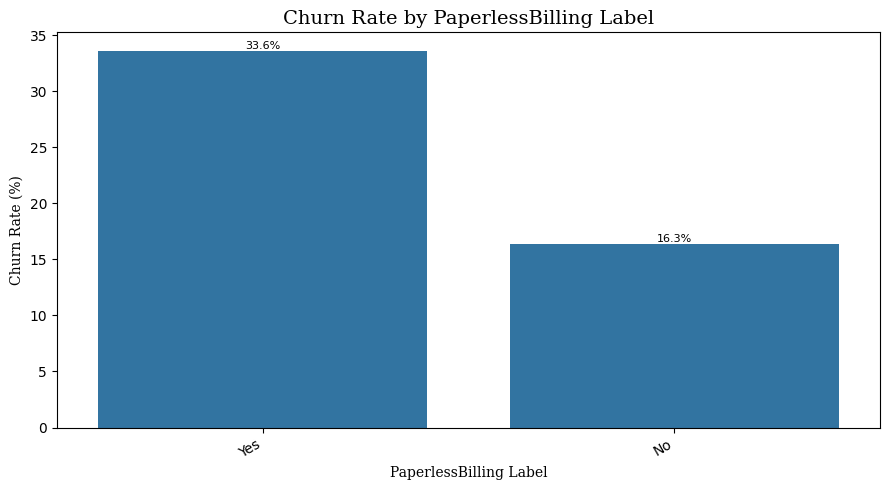

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_paperlessbilling_label.csv


,PaperlessBilling_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
1,Yes,4171,1400,0.335651,33.57
0,No,2872,469,0.163301,16.33


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_seniorcitizen_label.png


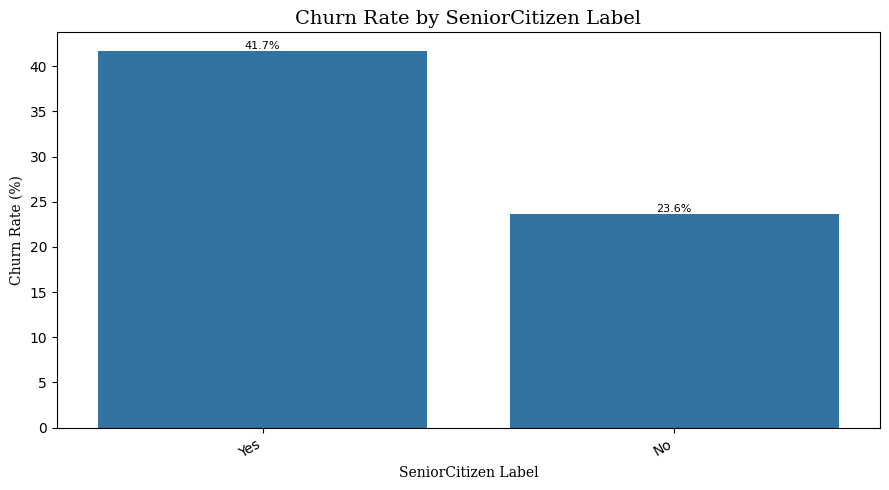

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_seniorcitizen_label.csv


,SeniorCitizen_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
1,Yes,1142,476,0.416813,41.68
0,No,5901,1393,0.236062,23.61


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_partner_label.png


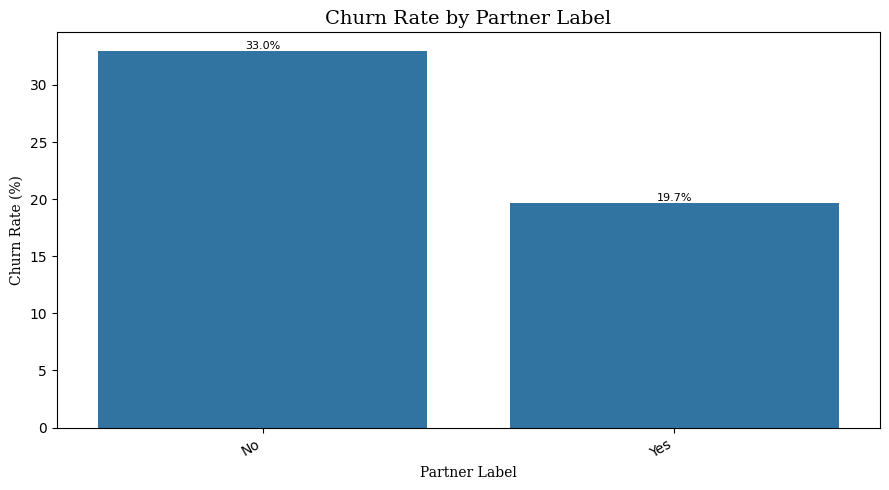

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_partner_label.csv


,Partner_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
0,No,3641,1200,0.329580,32.96
1,Yes,3402,669,0.196649,19.66


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_dependents.png


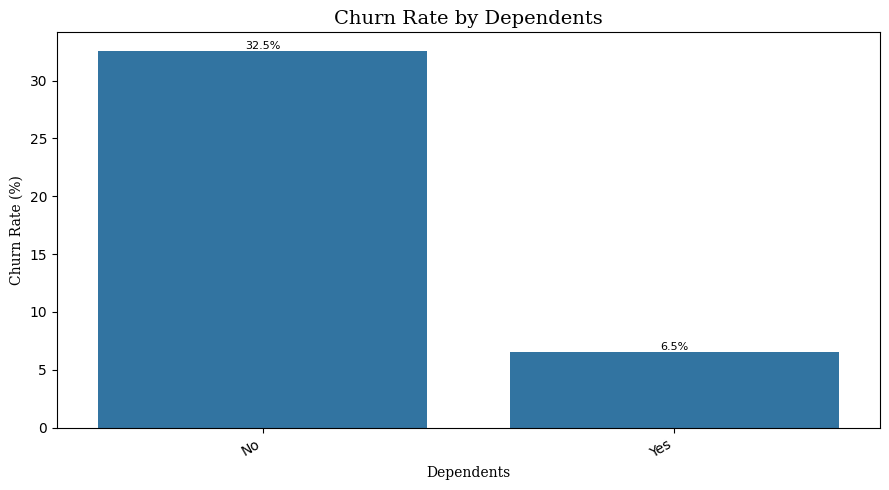

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_dependents.csv


,Dependents,total_customers,churn_customers,churn_rate,churn_rate_percent
0,No,5416,1763,0.325517,32.55
1,Yes,1627,106,0.065151,6.52


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_onlinesecurity_label.png


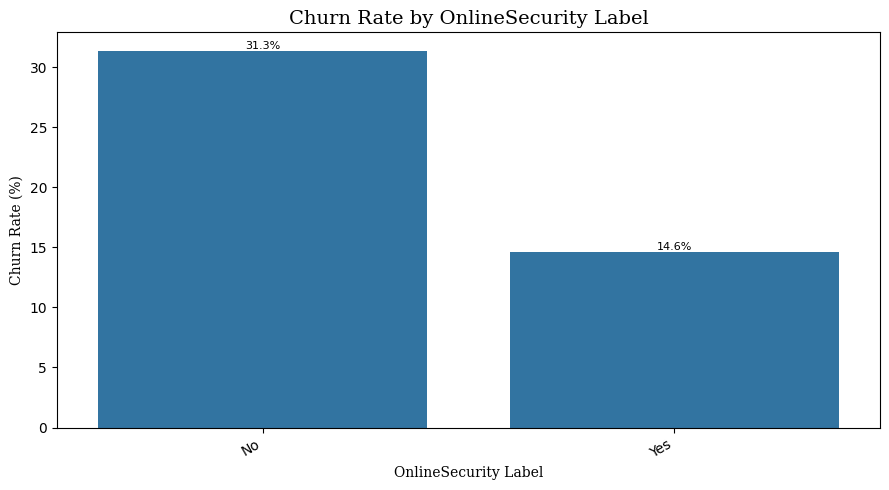

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_onlinesecurity_label.csv


,OnlineSecurity_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
0,No,5024,1574,0.313296,31.33
1,Yes,2019,295,0.146112,14.61


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_onlinebackup_label.png


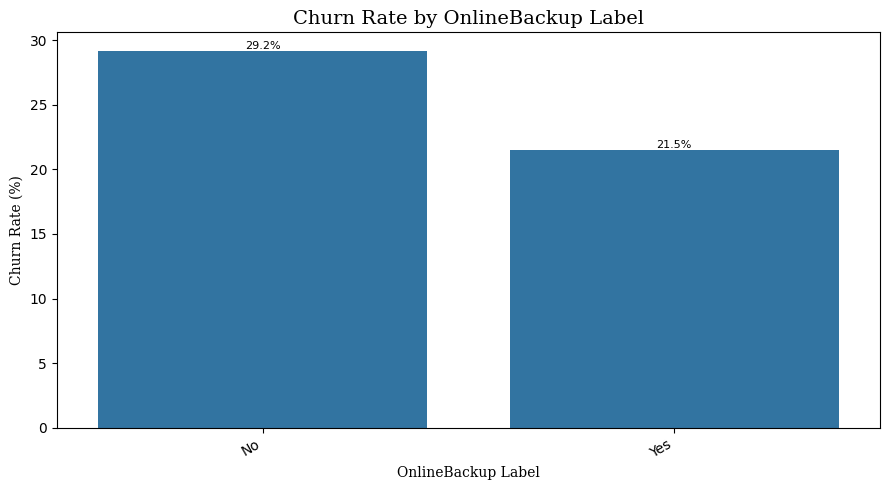

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_onlinebackup_label.csv


,OnlineBackup_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
0,No,4614,1346,0.291721,29.17
1,Yes,2429,523,0.215315,21.53


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_deviceprotection_label.png


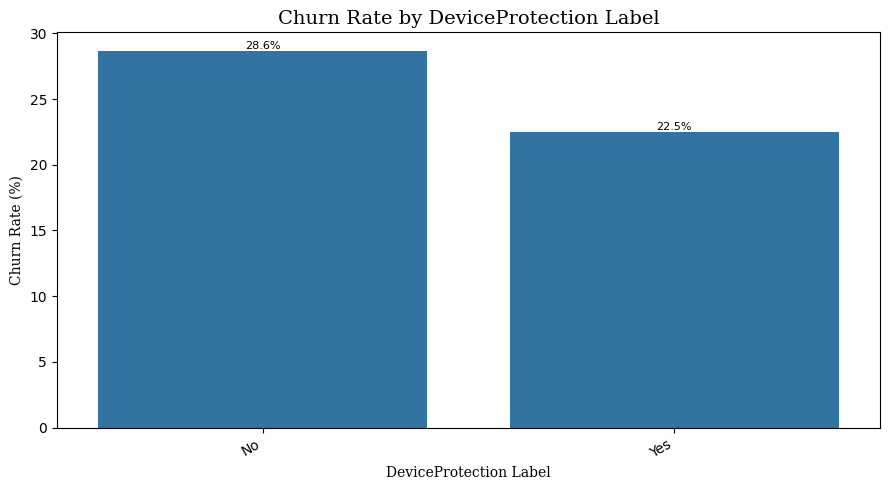

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_deviceprotection_label.csv


,DeviceProtection_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
0,No,4621,1324,0.286518,28.65
1,Yes,2422,545,0.225021,22.50


✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_techsupport_label.png


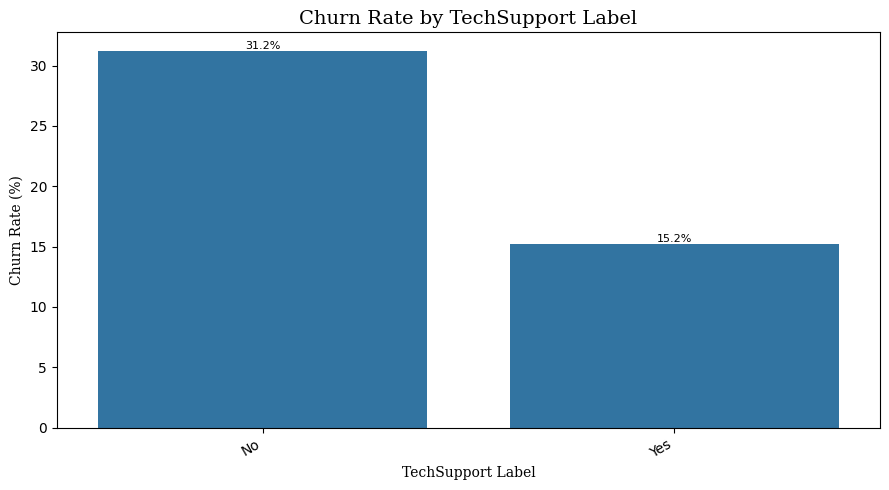

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_techsupport_label.csv


,TechSupport_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
0,No,4999,1559,0.311862,31.19
1,Yes,2044,310,0.151663,15.17


In [7]:
# =====================================================
# Churn rate by key categorical variables
# =====================================================
categorical_analysis_cols = []

candidate_cols = [
    "Contract_Label",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling_Label",
    "SeniorCitizen_Label",
    "Partner_Label",
    "Dependents",
    "OnlineSecurity_Label",
    "OnlineBackup_Label",
    "DeviceProtection_Label",
    "TechSupport_Label"
]

for col in candidate_cols:
    if col in df_eda.columns:
        categorical_analysis_cols.append(col)

print("Categorical columns used for churn-rate analysis:")
print(categorical_analysis_cols)


all_churn_rate_tables = {}

for col in categorical_analysis_cols:
    filename_safe = col.lower().replace(" ", "_").replace("/", "_")
    
    table = plot_churn_rate_bar(
        dataframe=df_eda,
        group_col=col,
        title=f"Churn Rate by {clean_label(col)}",
        filename=f"churn_rate_by_{filename_safe}.png"
    )
    
    all_churn_rate_tables[col] = table
    save_table(table, f"churn_rate_by_{filename_safe}.csv")
    display(table)

Cell 8 — Numeric analysis by Churn

In [8]:
# =====================================================
# Numeric feature comparison by churn status
# =====================================================
numeric_cols = []

candidate_numeric_cols = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "service_diversity",
    "monthly_charges_ratio"
]

for col in candidate_numeric_cols:
    if col in df_eda.columns:
        numeric_cols.append(col)

print("Numeric columns used for analysis:")
print(numeric_cols)


numeric_summary_by_churn = (
    df_eda
    .groupby("Churn_Label")[numeric_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(numeric_summary_by_churn)

numeric_summary_by_churn.to_csv(EDA_TABLES_DIR / "numeric_summary_by_churn.csv")
print(f"✅ Saved table: {EDA_TABLES_DIR / 'numeric_summary_by_churn.csv'}")

Numeric columns used for analysis:
['Tenure', 'MonthlyCharges', 'TotalCharges']


Tenure                                      MonthlyCharges  \
             count       mean median        std min max          count   
Churn_Label                                                              
Churn         1869  17.979133   10.0  19.531123   1  72           1869   
Non-Churn     5174  37.569965   38.0  24.113777   0  72           5174   

                                                         TotalCharges  \
                  mean  median        std    min     max        count   
Churn_Label                                                             
Churn        74.441332  79.650  24.666053  18.85  118.35         1869   
Non-Churn    61.265124  64.425  31.092648  18.25  118.75         5174   

                                                                 
                    mean    median          std    min      max  
Churn_Label                                                      
Churn        1531.796094   703.550  1890.822994  18.85  8684.80  
Non-Churn    2549.911442  1679.525  2329.954215   0.00  8672.45

✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\numeric_summary_by_churn.csv


Cell 9 — Boxplots for numeric variables

✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\tenure_by_churn_boxplot.png


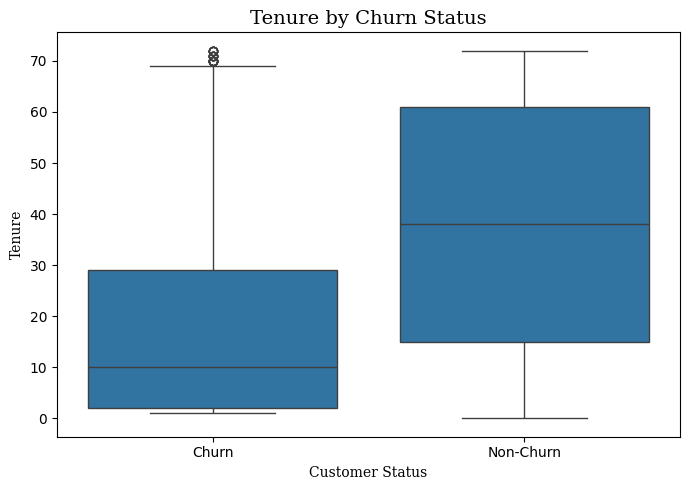

✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\monthlycharges_by_churn_boxplot.png


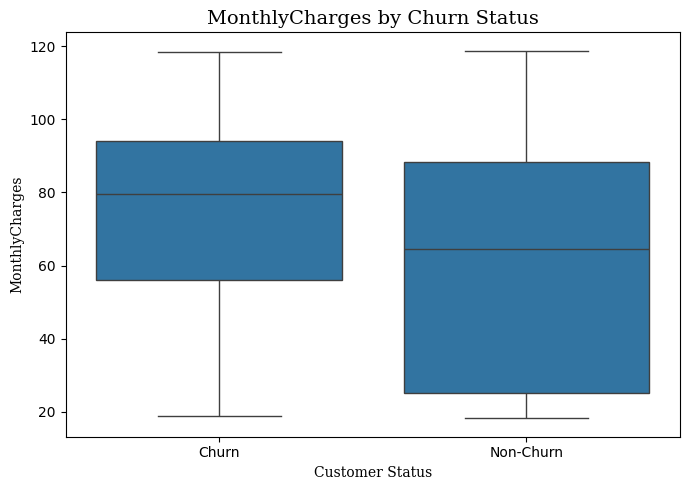

✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\totalcharges_by_churn_boxplot.png


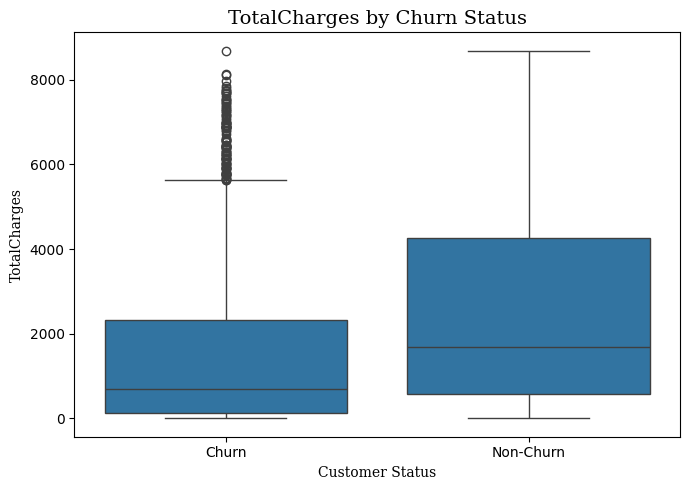

In [9]:
# =====================================================
# Boxplots for numeric variables by churn status
# =====================================================
for col in numeric_cols:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data=df_eda,
        x="Churn_Label",
        y=col
    )

    plt.title(f"{clean_label(col)} by Churn Status", fontfamily="serif", fontsize=14)
    plt.xlabel("Customer Status", fontfamily="serif")
    plt.ylabel(clean_label(col), fontfamily="serif")

    plt.tight_layout()
    filename = f"{col.lower()}_by_churn_boxplot.png"
    save_current_figure(filename)
    plt.show()

Cell 10 — Service gap analysis

In [10]:
# =====================================================
# Service gap analysis
# =====================================================
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

available_service_cols = [col for col in service_cols if col in df_eda.columns]

service_gap_tables = []

for col in available_service_cols:
    table = churn_rate_table(df_eda, col)
    table.insert(0, "service_feature", col)
    service_gap_tables.append(table)

if service_gap_tables:
    service_gap_df = pd.concat(service_gap_tables, ignore_index=True)
    service_gap_df = service_gap_df.sort_values("churn_rate_percent", ascending=False)

    display(service_gap_df)
    save_table(service_gap_df, "service_gap_analysis.csv")
else:
    print("No service columns available for service gap analysis.")

,service_feature,OnlineSecurity,total_customers,churn_customers,churn_rate,churn_rate_percent,OnlineBackup,DeviceProtection,TechSupport
0,OnlineSecurity,0.0,5024,1574,0.313296,31.33,NaN,NaN,NaN
6,TechSupport,NaN,4999,1559,0.311862,31.19,NaN,NaN,0.0
2,OnlineBackup,NaN,4614,1346,0.291721,29.17,0.0,NaN,NaN
4,DeviceProtection,NaN,4621,1324,0.286518,28.65,NaN,0.0,NaN
5,DeviceProtection,NaN,2422,545,0.225021,22.50,NaN,1.0,NaN
3,OnlineBackup,NaN,2429,523,0.215315,21.53,1.0,NaN,NaN
7,TechSupport,NaN,2044,310,0.151663,15.17,NaN,NaN,1.0
1,OnlineSecurity,1.0,2019,295,0.146112,14.61,NaN,NaN,NaN


✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\service_gap_analysis.csv


Cell 11 — Top risk segment analysis

In [11]:
# =====================================================
# Top risk segment analysis
# =====================================================
segment_cols = []

candidate_segment_cols = [
    "InternetService",
    "Contract_Label",
    "PaymentMethod",
    "TechSupport_Label",
    "OnlineSecurity_Label",
    "PaperlessBilling_Label"
]

for col in candidate_segment_cols:
    if col in df_eda.columns:
        segment_cols.append(col)

print("Segment columns:", segment_cols)

if len(segment_cols) >= 2:
    top_risk_segments = (
        df_eda
        .groupby(segment_cols, dropna=False)
        .agg(
            total_customers=("Churn", "count"),
            churn_customers=("Churn", "sum"),
            churn_rate=("Churn", "mean")
        )
        .reset_index()
    )

    top_risk_segments["churn_rate_percent"] = (top_risk_segments["churn_rate"] * 100).round(2)

    # Tránh segment quá nhỏ gây nhiễu
    min_customers = 20
    top_risk_segments = top_risk_segments[
        top_risk_segments["total_customers"] >= min_customers
    ]

    top_risk_segments = top_risk_segments.sort_values(
        ["churn_rate_percent", "total_customers"],
        ascending=[False, False]
    )

    display(top_risk_segments.head(20))
    save_table(top_risk_segments, "top_risk_segments.csv")
else:
    print("Not enough segment columns for risk segment analysis.")

Segment columns: ['InternetService', 'Contract_Label', 'PaymentMethod', 'TechSupport_Label', 'OnlineSecurity_Label', 'PaperlessBilling_Label']


,InternetService,Contract_Label,PaymentMethod,TechSupport_Label,OnlineSecurity_Label,PaperlessBilling_Label,total_customers,churn_customers,churn_rate,churn_rate_percent
113,Fiber optic,Month-to-month,Electronic check,No,No,Yes,816,556,0.681373,68.14
125,Fiber optic,Month-to-month,Mailed check,Yes,No,Yes,22,13,0.590909,59.09
121,Fiber optic,Month-to-month,Mailed check,No,No,Yes,94,53,0.563830,56.38
112,Fiber optic,Month-to-month,Electronic check,No,No,No,173,95,0.549133,54.91
97,Fiber optic,Month-to-month,Bank transfer (automatic),No,No,Yes,161,87,0.540373,54.04
120,Fiber optic,Month-to-month,Mailed check,No,No,No,43,23,0.534884,53.49
17,DSL,Month-to-month,Electronic check,No,No,Yes,182,93,0.510989,51.10
105,Fiber optic,Month-to-month,Credit card (automatic),No,No,Yes,152,76,0.500000,50.00
117,Fiber optic,Month-to-month,Electronic check,Yes,No,Yes,110,54,0.490909,49.09
115,Fiber optic,Month-to-month,Electronic check,No,Yes,Yes,110,52,0.472727,47.27


✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\top_risk_segments.csv


Cell 12 — Correlation heatmap

✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\correlation_heatmap.png


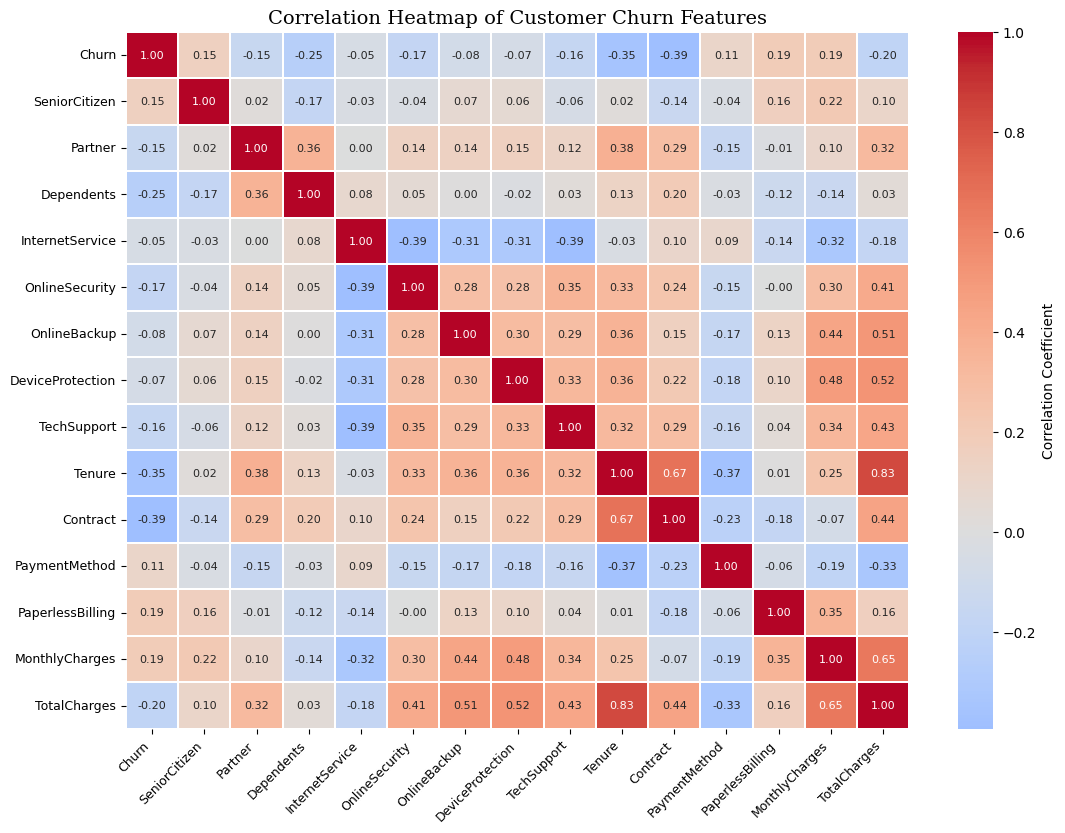

,feature,correlation_with_churn
0,Contract,-0.39
1,Tenure,-0.35
2,Dependents,-0.25
3,TotalCharges,-0.20
4,MonthlyCharges,0.19
5,PaperlessBilling,0.19
6,OnlineSecurity,-0.17
7,TechSupport,-0.16
8,SeniorCitizen,0.15
9,Partner,-0.15


✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\correlation_with_churn.csv


In [15]:
# =====================================================
# Correlation heatmap with annotated correlation values
# =====================================================
corr_df = df_eda.copy()

# Drop ID if exists
corr_df = corr_df.drop(columns=["ID"], errors="ignore")

# Drop label helper columns to avoid duplicated information
label_cols_to_drop = [col for col in corr_df.columns if col.endswith("_Label")]
corr_df = corr_df.drop(columns=label_cols_to_drop, errors="ignore")

# Convert object/category columns into category codes for correlation overview only
for col in corr_df.columns:
    if corr_df[col].dtype == "object" or str(corr_df[col].dtype) == "category":
        corr_df[col] = corr_df[col].astype("category").cat.codes

# Compute correlation matrix
corr_matrix = corr_df.corr(numeric_only=True)

# Dynamic figure size based on number of features
n_features = len(corr_matrix.columns)
fig_size = max(10, n_features * 0.75)

plt.figure(figsize=(fig_size, fig_size * 0.75))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    annot=True,
    fmt=".2f",
    annot_kws={
        "size": 8
    },
    cbar_kws={
        "label": "Correlation Coefficient"
    }
)

plt.title(
    "Correlation Heatmap of Customer Churn Features",
    fontfamily="serif",
    fontsize=14
)

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
save_current_figure("correlation_heatmap.png")
plt.show()

# Correlation with Churn
corr_with_churn = (
    corr_matrix["Churn"]
    .drop("Churn", errors="ignore")
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .reset_index()
)

corr_with_churn.columns = ["feature", "correlation_with_churn"]
corr_with_churn["correlation_with_churn"] = corr_with_churn["correlation_with_churn"].round(2)

display(corr_with_churn)
save_table(corr_with_churn, "correlation_with_churn.csv")

Cell 13 — Key EDA findings auto-summary

In [13]:
# =====================================================
# Auto-generate key EDA findings
# =====================================================
findings = []

overall_churn_rate = df_eda["Churn"].mean() * 100
findings.append(f"Overall churn rate: {overall_churn_rate:.2f}%.")

for col, table in all_churn_rate_tables.items():
    if not table.empty:
        top_row = table.iloc[0]
        segment_value = top_row[col]
        churn_rate = top_row["churn_rate_percent"]
        total_customers = top_row["total_customers"]

        findings.append(
            f"Highest churn segment by {clean_label(col)}: {segment_value} "
            f"with churn rate {churn_rate:.2f}% across {total_customers} customers."
        )

if numeric_cols:
    churn_numeric_mean = (
        df_eda
        .groupby("Churn_Label")[numeric_cols]
        .mean()
        .round(2)
    )

    findings.append("Numeric feature comparison by churn status:")
    findings.append(churn_numeric_mean.to_string())

print("\n".join(findings))

findings_path = EDA_TABLES_DIR / "eda_key_findings.txt"

with open(findings_path, "w", encoding="utf-8") as f:
    f.write("\n".join(findings))

print(f"\n✅ Saved EDA findings: {findings_path}")

Overall churn rate: 26.54%.
Highest churn segment by Contract Label: Month-to-month with churn rate 42.71% across 3875 customers.
Highest churn segment by InternetService: Fiber optic with churn rate 41.89% across 3096 customers.
Highest churn segment by PaymentMethod: Electronic check with churn rate 45.29% across 2365 customers.
Highest churn segment by PaperlessBilling Label: Yes with churn rate 33.57% across 4171 customers.
Highest churn segment by SeniorCitizen Label: Yes with churn rate 41.68% across 1142 customers.
Highest churn segment by Partner Label: No with churn rate 32.96% across 3641 customers.
Highest churn segment by Dependents: No with churn rate 32.55% across 5416 customers.
Highest churn segment by OnlineSecurity Label: No with churn rate 31.33% across 5024 customers.
Highest churn segment by OnlineBackup Label: No with churn rate 29.17% across 4614 customers.
Highest churn segment by DeviceProtection Label: No with churn rate 28.65% across 4621 customers.
Highest c

Cell 14 — Final EDA output check

In [14]:
# =====================================================
# Final output check
# =====================================================
print("✅ EDA completed.")
print(f"Figures saved to: {EDA_FIGURES_DIR}")
print(f"Tables saved to: {EDA_TABLES_DIR}")

print("\nGenerated figures:")
for path in sorted(EDA_FIGURES_DIR.glob("*.png")):
    print(f"- {path.name}")

print("\nGenerated tables:")
for path in sorted(EDA_TABLES_DIR.glob("*")):
    print(f"- {path.name}")

✅ EDA completed.
Figures saved to: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda
Tables saved to: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda

Generated figures:
- churn_distribution.png
- churn_rate_by_contract_label.png
- churn_rate_by_dependents.png
- churn_rate_by_deviceprotection_label.png
- churn_rate_by_internetservice.png
- churn_rate_by_onlinebackup_label.png
- churn_rate_by_onlinesecurity_label.png
- churn_rate_by_paperlessbilling_label.png
- churn_rate_by_partner_label.png
- churn_rate_by_paymentmethod.png
- churn_rate_by_seniorcitizen_label.png
- churn_rate_by_techsupport_label.png
- correlation_heatmap.png
- monthlycharges_by_churn_boxplot.png
- tenure_by_churn_boxplot.png
- totalcharges_by_churn_boxplot.png

Generated tables:
- churn_distribution.csv
- churn_rate_by_contract_label.csv
- churn_rate_by_dependents.csv
- churn_rate_by_deviceprotection_label.csv
- churn_rate_by_internetservice.csv
- churn_rate_by_onlinebackup_labe

In [16]:
# =====================================================
# Check engineered features status
# =====================================================
required_engineered_features = [
    "tenure_group",
    "service_diversity",
    "monthly_charges_ratio",
    "is_paperless_electronic"
]

existing_engineered_features = [
    col for col in required_engineered_features
    if col in df.columns
]

missing_engineered_features = [
    col for col in required_engineered_features
    if col not in df.columns
]

print("Required engineered features:")
print(required_engineered_features)

print("\nExisting engineered features:")
print(existing_engineered_features)

print("\nMissing engineered features:")
print(missing_engineered_features)

if missing_engineered_features:
    print("\n⚠️ Feature creator has NOT been fully applied to this dataset.")
else:
    print("\n✅ All required engineered features already exist in the dataset.")

Required engineered features:
['tenure_group', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']

Existing engineered features:
[]

Missing engineered features:
['tenure_group', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']

⚠️ Feature creator has NOT been fully applied to this dataset.


Cell — Feature Creator for EDA

In [17]:
# =====================================================
# EDA Feature Creator
# =====================================================
# These engineered features are created for EDA and reporting purposes.
# For model training, features that depend on dataset statistics must be recreated after train/test split.

df_eda = df_eda.copy()

# -----------------------------------------------------
# 1. tenure_group
# -----------------------------------------------------
if "Tenure" in df_eda.columns and "tenure_group" not in df_eda.columns:
    df_eda["tenure_group"] = pd.cut(
        df_eda["Tenure"],
        bins=[-1, 12, 24, 48, 60, np.inf],
        labels=["0-12 months", "13-24 months", "25-48 months", "49-60 months", "60+ months"]
    ).astype(str)

# -----------------------------------------------------
# 2. service_diversity
# -----------------------------------------------------
available_service_cols = [
    col for col in [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport"
    ]
    if col in df_eda.columns
]

if available_service_cols and "service_diversity" not in df_eda.columns:
    df_eda["service_diversity"] = df_eda[available_service_cols].apply(
        lambda row: sum(str(value).strip().lower() in ["1", "yes", "true"] for value in row),
        axis=1
    )

# -----------------------------------------------------
# 3. monthly_charges_ratio
# -----------------------------------------------------
if "MonthlyCharges" in df_eda.columns and "monthly_charges_ratio" not in df_eda.columns:
    avg_monthly_charges = df_eda["MonthlyCharges"].mean()
    df_eda["monthly_charges_ratio"] = df_eda["MonthlyCharges"] / avg_monthly_charges

    print(f"Average Monthly Charges used for EDA ratio: {avg_monthly_charges:.2f}")

# -----------------------------------------------------
# 4. is_paperless_electronic
# -----------------------------------------------------
if (
    "PaperlessBilling" in df_eda.columns
    and "PaymentMethod" in df_eda.columns
    and "is_paperless_electronic" not in df_eda.columns
):
    df_eda["is_paperless_electronic"] = np.where(
        (df_eda["PaperlessBilling"].astype(str).str.lower().isin(["1", "yes", "true"]))
        & (
            df_eda["PaymentMethod"]
            .astype(str)
            .str.lower()
            .str.contains("electronic", na=False)
        ),
        "Yes",
        "No"
    )

# -----------------------------------------------------
# Check created features
# -----------------------------------------------------
engineered_features = [
    "tenure_group",
    "service_diversity",
    "monthly_charges_ratio",
    "is_paperless_electronic"
]

existing_engineered_features = [
    col for col in engineered_features
    if col in df_eda.columns
]

print("✅ Existing engineered features:")
print(existing_engineered_features)

display(df_eda[existing_engineered_features].head())

Average Monthly Charges used for EDA ratio: 64.76
✅ Existing engineered features:
['tenure_group', 'service_diversity', 'monthly_charges_ratio', 'is_paperless_electronic']


,tenure_group,service_diversity,monthly_charges_ratio,is_paperless_electronic
0,0-12 months,2,0.831510,No
1,0-12 months,0,1.091695,Yes
2,0-12 months,1,1.538718,Yes
3,25-48 months,2,1.618241,Yes
4,49-60 months,2,1.601255,No


Cell — Update analysis columns sau khi tạo feature

In [18]:
# =====================================================
# Update EDA analysis columns after feature creation
# =====================================================

candidate_numeric_cols = [
    "Tenure",
    "MonthlyCharges",
    "TotalCharges",
    "service_diversity",
    "monthly_charges_ratio"
]

numeric_cols = [
    col for col in candidate_numeric_cols
    if col in df_eda.columns
]

candidate_categorical_cols = [
    "Contract_Label",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling_Label",
    "SeniorCitizen_Label",
    "Partner_Label",
    "Dependents",
    "OnlineSecurity_Label",
    "OnlineBackup_Label",
    "DeviceProtection_Label",
    "TechSupport_Label",
    "tenure_group",
    "is_paperless_electronic"
]

categorical_analysis_cols = [
    col for col in candidate_categorical_cols
    if col in df_eda.columns
]

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical/group columns:")
print(categorical_analysis_cols)

Numeric columns:
['Tenure', 'MonthlyCharges', 'TotalCharges', 'service_diversity', 'monthly_charges_ratio']

Categorical/group columns:
['Contract_Label', 'InternetService', 'PaymentMethod', 'PaperlessBilling_Label', 'SeniorCitizen_Label', 'Partner_Label', 'Dependents', 'OnlineSecurity_Label', 'OnlineBackup_Label', 'DeviceProtection_Label', 'TechSupport_Label', 'tenure_group', 'is_paperless_electronic']


Cell — KDE plot cho monthly_charges_ratio

✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\kde_monthly_charges_ratio_by_churn.png


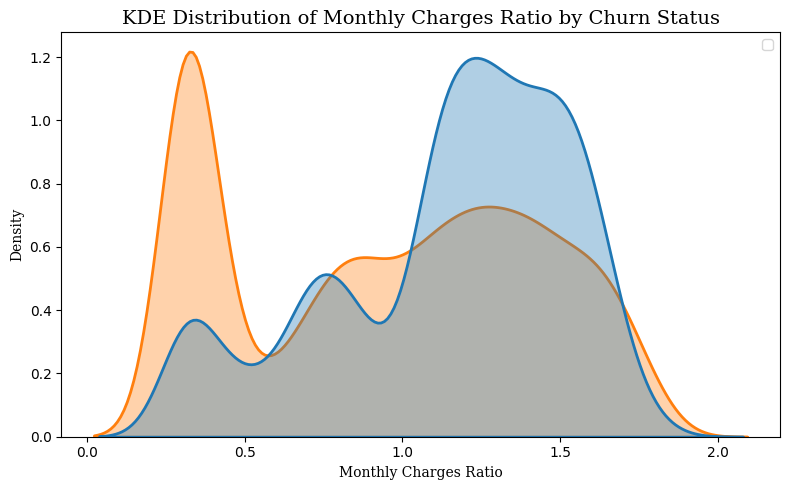

In [20]:
# =====================================================
# KDE Plot: Monthly Charges Ratio by Churn Status
# =====================================================

if "monthly_charges_ratio" in df_eda.columns and "Churn_Label" in df_eda.columns:
    plt.figure(figsize=(8, 5))

    sns.kdeplot(
        data=df_eda,
        x="monthly_charges_ratio",
        hue="Churn_Label",
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=2
    )

    plt.title(
        "KDE Distribution of Monthly Charges Ratio by Churn Status",
        fontfamily="serif",
        fontsize=14
    )

    plt.xlabel("Monthly Charges Ratio", fontfamily="serif")
    plt.ylabel("Density", fontfamily="serif")

    plt.legend()
    plt.tight_layout()

    save_current_figure("kde_monthly_charges_ratio_by_churn.png")
    plt.show()

else:
    print("⚠️ monthly_charges_ratio or Churn_Label is not available.")

Cell — Summary statistic cho monthly_charges_ratio

In [21]:
# =====================================================
# Monthly Charges Ratio Summary by Churn Status
# =====================================================

if "monthly_charges_ratio" in df_eda.columns and "Churn_Label" in df_eda.columns:
    monthly_ratio_summary = (
        df_eda
        .groupby("Churn_Label")["monthly_charges_ratio"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(2)
        .reset_index()
    )

    display(monthly_ratio_summary)
    save_table(monthly_ratio_summary, "monthly_charges_ratio_summary_by_churn.csv")

else:
    print("⚠️ monthly_charges_ratio or Churn_Label is not available.")

,Churn_Label,count,mean,median,std,min,max
0,Churn,1869,1.15,1.23,0.38,0.29,1.83
1,Non-Churn,5174,0.95,0.99,0.48,0.28,1.83


✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\monthly_charges_ratio_summary_by_churn.csv


Cell — Churn rate by monthly_charges_ratio group

,monthly_charges_ratio_group,total_customers,churn_customers,churn_rate,churn_rate_percent
1,High (1.0-1.2x Avg),1007,348,0.345581,34.56
3,Very High (>1.2x Avg),2916,1007,0.345336,34.53
0,Average (0.8-1.0x Avg),667,110,0.164918,16.49
2,Low (<0.8x Avg),2453,404,0.164696,16.47


✅ Saved table: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\data_reports\eda\churn_rate_by_monthly_charges_ratio_group.csv
✅ Saved figure: D:\FPTU_Study\SU2026\ADY201m\Predictive_Churn\reports\figures\eda\churn_rate_by_monthly_charges_ratio_group.png


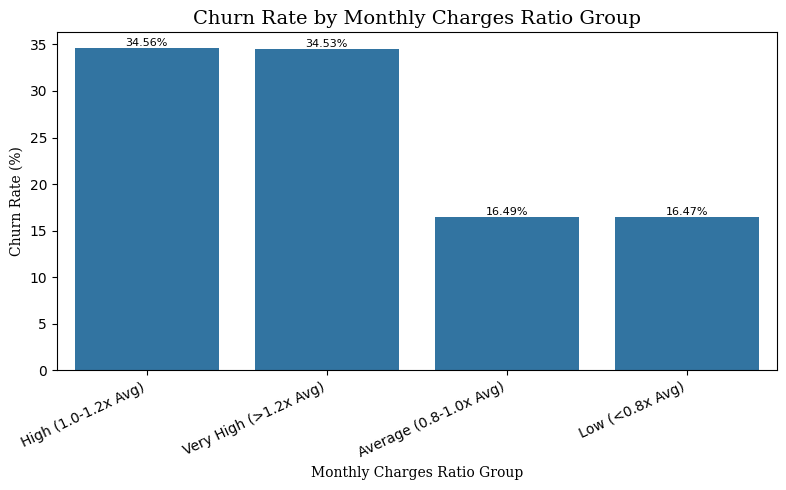

In [22]:
# =====================================================
# Churn Rate by Monthly Charges Ratio Group
# =====================================================

if "monthly_charges_ratio" in df_eda.columns:
    df_eda["monthly_charges_ratio_group"] = pd.cut(
        df_eda["monthly_charges_ratio"],
        bins=[0, 0.8, 1.0, 1.2, np.inf],
        labels=[
            "Low (<0.8x Avg)",
            "Average (0.8-1.0x Avg)",
            "High (1.0-1.2x Avg)",
            "Very High (>1.2x Avg)"
        ]
    ).astype(str)

    monthly_ratio_group_table = churn_rate_table(
        dataframe=df_eda,
        group_col="monthly_charges_ratio_group"
    )

    display(monthly_ratio_group_table)
    save_table(monthly_ratio_group_table, "churn_rate_by_monthly_charges_ratio_group.csv")

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        data=monthly_ratio_group_table,
        x="monthly_charges_ratio_group",
        y="churn_rate_percent"
    )

    plt.title(
        "Churn Rate by Monthly Charges Ratio Group",
        fontfamily="serif",
        fontsize=14
    )
    plt.xlabel("Monthly Charges Ratio Group", fontfamily="serif")
    plt.ylabel("Churn Rate (%)", fontfamily="serif")
    plt.xticks(rotation=25, ha="right")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", fontsize=8)

    plt.tight_layout()
    save_current_figure("churn_rate_by_monthly_charges_ratio_group.png")
    plt.show()

else:
    print("⚠️ monthly_charges_ratio is not available.")